<a href="https://colab.research.google.com/github/siddhartha-sai-17/Machine_Learning/blob/main/SupportVectorMachine(Loan_Prediction_Problem_Dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files
uploaded = files.upload()

Saving test_Y3wMUE5_7gLdaTN.csv to test_Y3wMUE5_7gLdaTN (1).csv


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')

In [10]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [11]:
df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [12]:
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [14]:
from sklearn.preprocessing import LabelEncoder
#Encode categorical values
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  label_encoders[col] = le

In [15]:
df['Gender']

,Gender
0,1
1,1
2,1
4,1
5,1
...,...
361,1
362,1
363,1
365,1


In [16]:
df['Self_Employed']

,Self_Employed
0,0
1,0
2,0
4,0
5,1
...,...
361,0
362,1
363,0
365,0


In [17]:
df.drop("Loan_ID", axis=1, inplace=True)


In [18]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df.drop(["ApplicantIncome","CoapplicantIncome"], axis=1, inplace=True)


In [21]:
print(df.columns)


Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'TotalIncome'],
      dtype='object')


In [22]:
import os
print(os.listdir())


['.config', 'test_Y3wMUE5_7gLdaTN.csv', 'test_Y3wMUE5_7gLdaTN (1).csv', 'sample_data']


In [25]:
from google.colab import files
uploaded = files.upload()

Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i.csv


In [26]:
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

In [27]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [28]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [29]:
df.dropna(inplace=True)

In [31]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [32]:
from sklearn.preprocessing import LabelEncoder
df.dropna(inplace=True)
#Encode categorical values
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  label_encoders[col] = le

In [33]:
X = df.drop("Loan_Status",axis=1)
y = df["Loan_Status"]

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_linear))
print(confusion_matrix(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))


Linear SVM Accuracy: 0.8229166666666666
[[11 17]
 [ 0 68]]
              precision    recall  f1-score   support

           0       1.00      0.39      0.56        28
           1       0.80      1.00      0.89        68

    accuracy                           0.82        96
   macro avg       0.90      0.70      0.73        96
weighted avg       0.86      0.82      0.79        96



In [46]:
# Train SVM wtih Polynomial Kernel
svm_poly = SVC(kernel='poly', degree=3, C=1)
svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)

print("Poly SVM Accuracy:", accuracy_score(y_test, y_pred_poly))
print(confusion_matrix(y_test, y_pred_poly))
print(classification_report(y_test, y_pred_poly))


Poly SVM Accuracy: 0.8020833333333334
[[10 18]
 [ 1 67]]
              precision    recall  f1-score   support

           0       0.91      0.36      0.51        28
           1       0.79      0.99      0.88        68

    accuracy                           0.80        96
   macro avg       0.85      0.67      0.69        96
weighted avg       0.82      0.80      0.77        96



In [47]:
# Train SVM with RBF kernel
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("RBF SVM Accuracy:", accuracy_score(y_test, y_pred_rbf))
print(confusion_matrix(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))


RBF SVM Accuracy: 0.8125
[[11 17]
 [ 1 67]]
              precision    recall  f1-score   support

           0       0.92      0.39      0.55        28
           1       0.80      0.99      0.88        68

    accuracy                           0.81        96
   macro avg       0.86      0.69      0.72        96
weighted avg       0.83      0.81      0.78        96



In [48]:
(df.isnull().sum() / len(df)) * 100


,0
Loan_ID,0.0
Gender,0.0
Married,0.0
Dependents,0.0
Education,0.0
Self_Employed,0.0
ApplicantIncome,0.0
CoapplicantIncome,0.0
LoanAmount,0.0
Loan_Amount_Term,0.0


In [51]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

# Example: assuming you have y_test and predictions
metrics = {}

# Linear SVM
metrics['Linear'] = {
    'Accuracy': accuracy_score(y_test, y_pred_linear),
    'Reject Recall': recall_score(y_test, y_pred_linear, pos_label=0),
    'F1': f1_score(y_test, y_pred_linear, pos_label=0),
    'Confusion': confusion_matrix(y_test, y_pred_linear)
}

# Polynomial SVM
metrics['Poly'] = {
    'Accuracy': accuracy_score(y_test, y_pred_poly),
    'Reject Recall': recall_score(y_test, y_pred_poly, pos_label=0),
    'F1': f1_score(y_test, y_pred_poly, pos_label=0),
    'Confusion': confusion_matrix(y_test, y_pred_poly)
}

# RBF SVM
metrics['RBF'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rbf),
    'Reject Recall': recall_score(y_test, y_pred_rbf, pos_label=0),
    'F1': f1_score(y_test, y_pred_rbf, pos_label=0),
    'Confusion': confusion_matrix(y_test, y_pred_rbf)
}


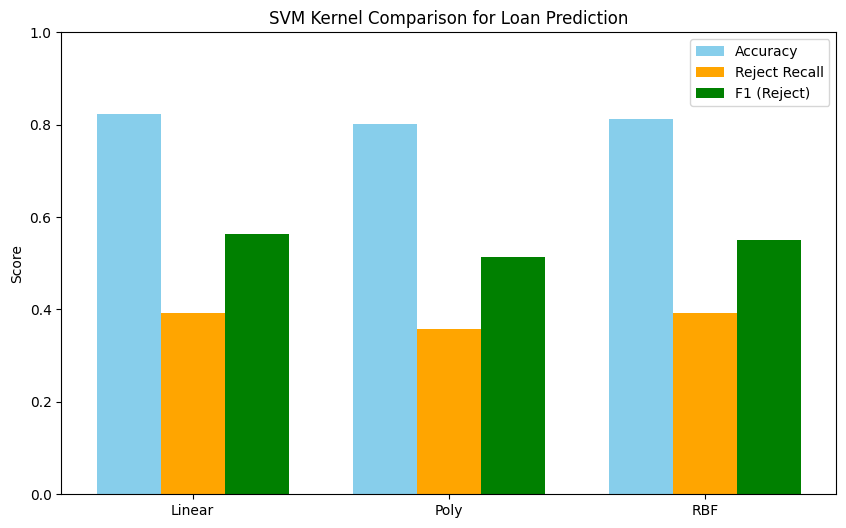

In [52]:
import matplotlib.pyplot as plt
import numpy as np

models = list(metrics.keys())
accuracy = [metrics[m]['Accuracy'] for m in models]
reject_recall = [metrics[m]['Reject Recall'] for m in models]
f1_scores = [metrics[m]['F1'] for m in models]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, accuracy, width, label='Accuracy', color='skyblue')
plt.bar(x, reject_recall, width, label='Reject Recall', color='orange')
plt.bar(x + width, f1_scores, width, label='F1 (Reject)', color='green')

plt.xticks(x, models)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("SVM Kernel Comparison for Loan Prediction")
plt.legend()
plt.show()


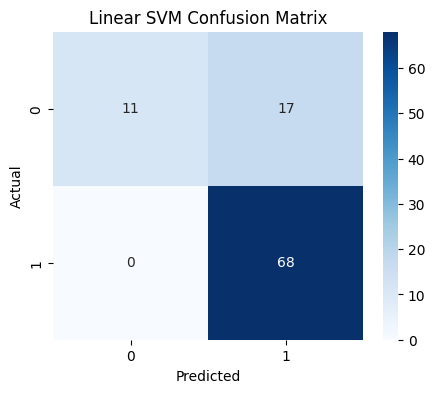

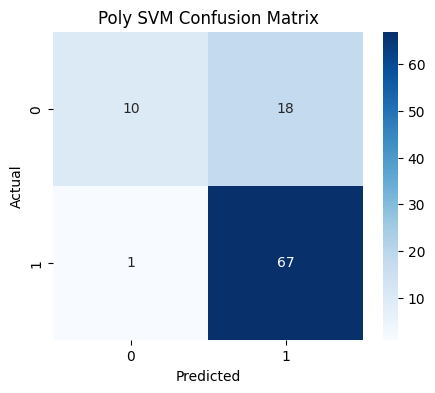

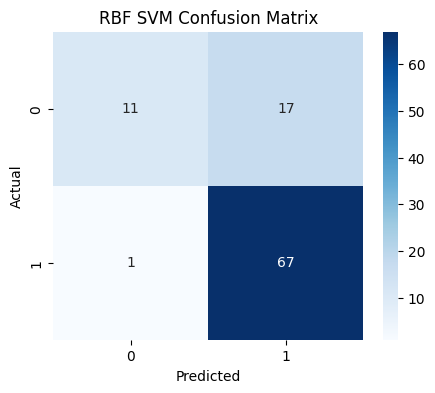

In [53]:
import seaborn as sns

for m in models:
    plt.figure(figsize=(5,4))
    sns.heatmap(metrics[m]['Confusion'], annot=True, fmt='d', cmap='Blues')
    plt.title(f"{m} SVM Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [55]:
import joblib

joblib.dump(svm_rbf, "/content/rbf_loan_model.pkl")
joblib.dump(scaler, "/content/scaler.pkl")
joblib.dump(label_encoders, "/content/encoders.pkl")


['/content/encoders.pkl']

In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C':[0.1,1,10], 'gamma':[0.01,0.1,1]}
grid = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

best_rbf = grid.best_estimator_


In [57]:
joblib.dump(best_rbf, "/content/rbf_loan_model.pkl")
joblib.dump(scaler, "/content/scaler.pkl")
joblib.dump(label_encoders, "/content/encoders.pkl")


['/content/encoders.pkl']

In [58]:
import joblib

# Example: save your trained RBF SVM, scaler, and label encoders
joblib.dump(best_rbf, "/content/rbf_loan_model.pkl")
joblib.dump(scaler, "/content/scaler.pkl")
joblib.dump(label_encoders, "/content/encoders.pkl")


['/content/encoders.pkl']